In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })


detections_narrow_ET = pd.read_csv("./detection_output/narrow_ET.dat", sep="    ")
detections_narrow_ET_CE = pd.read_csv("./detection_output/narrow_ET_CE.dat", sep="    ")
detections_wide_ET = pd.read_csv("./detection_output/wide_ET.dat", sep="    ")
detections_wide_ET_CE = pd.read_csv("./detection_output/wide_ET_CE.dat", sep="    ")

/tmp/ipykernel_30228/2269911081.py:14: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  detections_narrow_ET = pd.read_csv("./detection_output/narrow_ET.dat", sep="    ")
/tmp/ipykernel_30228/2269911081.py:15: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  detections_narrow_ET_CE = pd.read_csv("./detection_output/narrow_ET_CE.dat", sep="    ")
/tmp/ipykernel_30228/2269911081.py:16: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine=

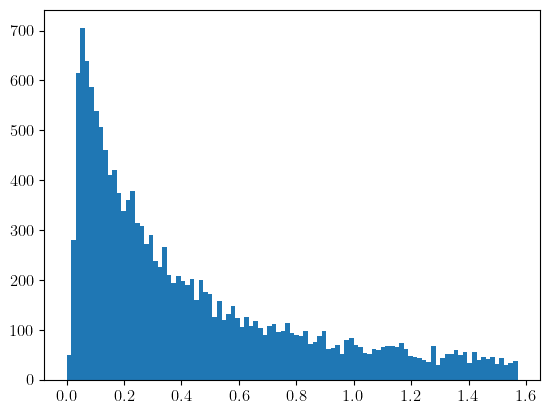

In [16]:
def plot_inclination_uncertainty(detections, df_FIM):

    kn_detected = np.sum(detections[["lssti", "lsstg", "ztfg", "ztfi", "ps1::g", "ps1::i", "ultrasat_custom"]], axis=1) >=2

    mask = (detections["DeltaOmega"] <=100) & (~kn_detected)

    #plt.scatter(y=df_FIM["theta_jn"][mask], x=detections["redshift"][mask])
    #plt.ylim(0, np.pi/2)

    plt.hist(df_FIM["theta_jn"][mask], bins=np.linspace(0, np.pi/2, 100))

plot_inclination_uncertainty(detections_wide_ET_CE, pd.read_csv("/home/aya/work/hkoehn/mma_analysis/catalogs/outdir_FIM/full_wide_ETL1_ETL2_CE_gwfish.dat", sep=" "))

In [20]:
def tb(log10_E0, n0, thetaCore, inclination):
    return 24.9 * 10**(1/3 * (log10_E0-53)) * n0**(-1/3) * ((inclination + 1.24*thetaCore)/0.5)**(8/3)

In [29]:
print(tb(52, 1e-4, np.deg2rad(5), np.pi/4-0.1), tb(52, 1e-4, np.deg2rad(5), np.pi/4), tb(52, 1e-4, np.deg2rad(5), np.pi/4+0.1))

853.5512640346822 1171.3109726661892 1554.2476530038525


In [42]:
print(tb(52, 1e-5, np.deg2rad(5), np.pi/4), tb(52, 1e-3, np.deg2rad(5), np.pi/4), tb(52, 1e0, np.deg2rad(5), np.pi/4))

2523.5129923270256 543.6743931415507 54.36743931415508


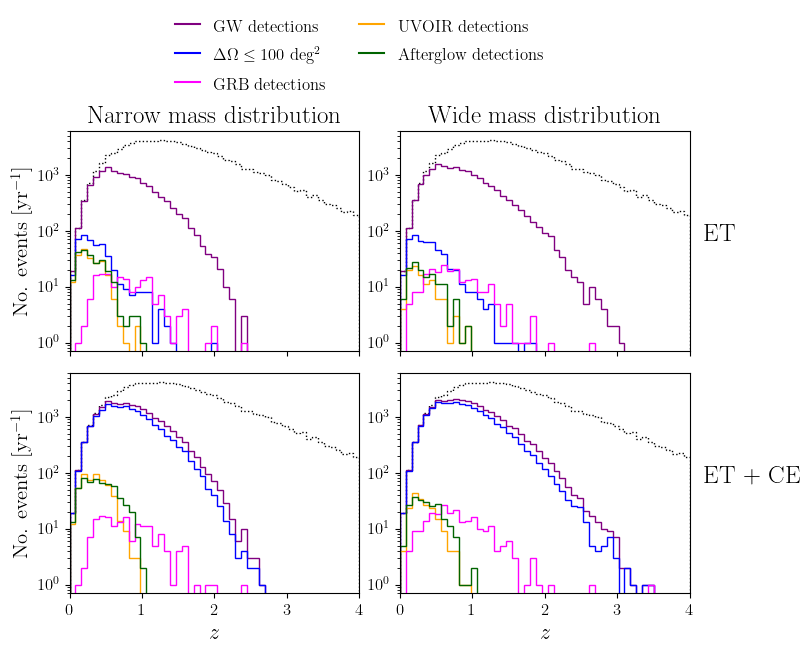

In [8]:
def plot_detections(ax, df):
    
    gw_detected = df["gw_detected"].astype(bool)
    grb_detected = df["grb_detected"].astype(bool)
    kn_detected = np.sum(df[["lsstg", "lssti", "ztfg", "ztfi", "ps1::i", "ps1::g", "ultrasat_custom"]], axis=1) >= 2
    #ztf_detected = (df["ztfg"] + df["ztfi"]) >= 2
    #pstarrs_detected = (df["ps1::i"] + df["ps1::g"]) >= 2
    #ultrasat_detected = (df["ultrasat_custom"]) >= 1
    sky_loc = df["DeltaOmega"] <= 100.
    afterglow_detected = np.sum(df[["radio_afterglow", "opt_afterglow", "xray_afterglow"]], axis=1) >= 1

    bins = np.linspace(0, 4, 50)
    ax.hist(df["redshift"], bins=bins, histtype = "step", color="black", linestyle="dotted")
    ax.hist(df["redshift"][gw_detected], bins=bins, histtype="step", color="purple", label="GW detections")
    ax.hist(df["redshift"][sky_loc], bins=bins, histtype="step", color="blue", label="$\\Delta\\Omega \\leq 100$ deg$^2$")
    ax.hist(df["redshift"][kn_detected], bins=bins, histtype="step", color="orange", label="KN detections")
    #ax.hist(df["redshift"][ztf_detected], bins=np.linspace(0, 4, 50), histtype="step", color="red")
    #ax.hist(df["redshift"][ultrasat_detected], bins=np.linspace(0, 4, 50), histtype="step", color="salmon")
    #ax.hist(df["redshift"][pstarrs_detected], bins=np.linspace(0, 4, 50), histtype="step", color="yellow")
    ax.hist(df["redshift"][grb_detected], bins=bins, histtype="step", color="magenta", label="GRB detections")
    ax.hist(df["redshift"][afterglow_detected], bins=bins, histtype="step", color="darkgreen", label="Afterglow detections")

    ax.set_yscale("log")
    ax.set_ylim((0.7, 6e3))



fig, ax = plt.subplots(2, 2, figsize= (8, 6), sharex=True)
fig.subplots_adjust(hspace=0.1, wspace=0.14)

ax[0,0].set_title("Narrow mass distribution", fontsize=18)
ax[0,0].set_ylabel("No. events [yr$^{-1}$]", fontsize=15)
plot_detections(ax[0,0], detections_narrow_ET)

ax[0,1].set_title("Wide mass distribution", fontsize=18)
ax[0,1].text(1.05, 0.5, "ET", rotation=0, transform=ax[0,1].transAxes, fontsize=18)
plot_detections(ax[0,1], detections_wide_ET)


plot_detections(ax[1,0], detections_narrow_ET_CE)
ax[1,0].set_ylabel("No. events [yr$^{-1}$]", fontsize=15)
ax[1,0].set_xlim(0, 4)
ax[1,0].set_xlabel("$z$", fontsize=16)


plot_detections(ax[1,1], detections_wide_ET_CE)
ax[1,1].set_xlim(0, 4)
ax[1,1].set_xlabel("$z$", fontsize=16)
ax[1,1].text(1.05, 0.5, "ET + CE", rotation=0, transform=ax[1,1].transAxes, fontsize=18)



labels = [r"GW detections", r"$\Delta\Omega\leq100$ deg$^2$", "GRB detections", "UVOIR detections", "Afterglow detections"]

lc1 = plt.plot([], [], color="purple")[0]
lc2 = plt.plot([], [], color="blue")[0]
lc3 = plt.plot([], [], color="magenta")[0]
lc4 = plt.plot([], [], color="orange")[0]
lc5 = plt.plot([], [], color="darkgreen",)[0]
ax[0,0].legend([lc1, lc2, lc3, lc4, lc5], 
                labels, 
                handlelength=1.5, handleheight=1.5,
                bbox_to_anchor=[1., 1.1],loc='lower center',frameon=False, ncol=2)

fig.savefig("../figures/detections.pdf", dpi=250, bbox_inches="tight")

In [5]:
def print_telt(df):

    print("ztf", np.sum(df["telt_ztf"])/(365*0.5), np.sum(np.sum(df[["ztfg", "ztfi"]], axis=1)>2))
    print("vr", np.sum(df["telt_vr"])/(365*0.5), np.sum(np.sum(df[["lsstg", "lssti"]], axis=1)>2))
    print("pstarrs", np.sum(df["telt_pstarrs"])/(365*0.5), np.sum(np.sum(df[["ps1::g", "ps1::i"]], axis=1)>2))
    print("ultrasat detections", np.sum(df["telt_ultrasat"])/(365), np.sum(df["ultrasat_custom"]))

print_telt(detections_narrow_ET_CE)

ztf 0.0308853373921867 6
vr 0.5890157280568236 239
pstarrs 0.04846524606798572 80
ultrasat detections 0.20011415525114126 39


In [6]:
detections_narrow_ET_CE.head()

,redshift,gw_detected,grb_detected,DeltaOmega,telt_vr,lsstg,lssti,telt_ztf,ztfg,ztfi,telt_pstarrs,ps1::g,ps1::i,telt_ultrasat,ultrasat_custom,radio_afterglow,opt_afterglow,xray_afterglow,telt_vr_afterglow
0,1.330,0,0,inf,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0,0,0.0
1,1.393,0,0,inf,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0,0,0.0
2,0.833,0,0,inf,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0,0,0.0
3,1.622,0,0,inf,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0,0,0.0
4,2.266,0,0,inf,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0,0,0.0
